# 08. Collaborative filtering with sparse cosine similarity

This notebook implements an item-item collaborative filtering recommender
using sparse implicit interactions and cosine similarity.

The model is trained on the chronological implicit training split only.
Recommendations are generated from item-item similarity and evaluated on
validation and test splits using Top-N ranking metrics.

Main tasks in this notebook:

- load chronological implicit train, validation, and test splits
- use the train-fitted mapped indices from Phase 5
- build a sparse user-item interaction matrix
- compute sparse item-item cosine similarity
- keep only the top neighbours per item for better scaling
- generate top-N recommendations for each user
- evaluate ranking quality on validation and test
- analyse coverage and recommendation concentration
- save outputs for later comparison and dashboard use

In [1]:
from __future__ import annotations

import json
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import sparse

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)

## 1. Set project paths

In [2]:
PROJECT_ROOT = Path.cwd().resolve().parents[0]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.paths import (
    SPLITS_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    LOGS_DIR,
    ensure_directories,
)

In [3]:
MODEL_NAME = "collaborative_filtering"

TOP_K_VALUES = [5, 10, 20]
EXPORT_TOP_N = 10

ITEM_NEIGHBOUR_K = 100
RECOMMENDATION_CANDIDATE_MULTIPLIER = 5

TABLES_SUBDIR = TABLES_DIR / MODEL_NAME
FIGURES_SUBDIR = FIGURES_DIR / MODEL_NAME
LOGS_SUBDIR = LOGS_DIR / MODEL_NAME

ensure_directories()
TABLES_SUBDIR.mkdir(parents=True, exist_ok=True)
FIGURES_SUBDIR.mkdir(parents=True, exist_ok=True)
LOGS_SUBDIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Split directory:", SPLITS_DIR)
print("Tables output:", TABLES_SUBDIR)
print("Figures output:", FIGURES_SUBDIR)
print("Logs output:", LOGS_SUBDIR)

Project root: E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project
Split directory: E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\data\splits
Tables output: E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\outputs\tables\collaborative_filtering
Figures output: E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\outputs\figures\collaborative_filtering
Logs output: E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\outputs\logs\collaborative_filtering


## 2. Load implicit chronological splits

These splits were created in Phase 5 and already include train-fitted
`user_idx` and `item_idx` columns for collaborative filtering.

In [4]:
train_path = SPLITS_DIR / "implicit_train.parquet"
valid_path = SPLITS_DIR / "implicit_valid.parquet"
test_path = SPLITS_DIR / "implicit_test.parquet"

implicit_train = pd.read_parquet(train_path).copy()
implicit_valid = pd.read_parquet(valid_path).copy()
implicit_test = pd.read_parquet(test_path).copy()

In [5]:
print("Implicit train shape:", implicit_train.shape)
print("Implicit valid shape:", implicit_valid.shape)
print("Implicit test shape:", implicit_test.shape)

print("\nTrain columns:")
print(list(implicit_train.columns))

Implicit train shape: (792656, 9)
Implicit valid shape: (169855, 9)
Implicit test shape: (169856, 9)

Train columns:
['user_id', 'recipe_id', 'date', 'rating', 'review_exists', 'is_unrated_observation', 'implicit_feedback', 'user_idx', 'item_idx']


In [6]:
required_cols = [
    "user_id",
    "recipe_id",
    "date",
    "implicit_feedback",
    "user_idx",
    "item_idx",
]

for name, df in {
    "implicit_train": implicit_train,
    "implicit_valid": implicit_valid,
    "implicit_test": implicit_test,
}.items():
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise ValueError(f"{name} is missing required columns: {missing}")

print("All required columns are present.")

All required columns are present.


In [7]:
for df in [implicit_train, implicit_valid, implicit_test]:
    df["date"] = pd.to_datetime(df["date"])

print("Train date range:", implicit_train["date"].min(), "to", implicit_train["date"].max())
print("Valid date range:", implicit_valid["date"].min(), "to", implicit_valid["date"].max())
print("Test date range:", implicit_test["date"].min(), "to", implicit_test["date"].max())

Train date range: 2000-01-25 00:00:00 to 2010-06-17 00:00:00
Valid date range: 2010-06-17 00:00:00 to 2012-12-28 00:00:00
Test date range: 2012-12-28 00:00:00 to 2018-12-20 00:00:00


## 3. Check mapped index coverage

Validation and test may contain unseen users or items, which produce missing
`user_idx` or `item_idx` values because mappings were fitted on train only.

In [8]:
mapping_summary = pd.DataFrame([
    {
        "split": "train",
        "rows": int(len(implicit_train)),
        "rows_missing_user_idx": int(implicit_train["user_idx"].isna().sum()),
        "rows_missing_item_idx": int(implicit_train["item_idx"].isna().sum()),
        "rows_missing_either_idx": int((implicit_train["user_idx"].isna() | implicit_train["item_idx"].isna()).sum()),
    },
    {
        "split": "valid",
        "rows": int(len(implicit_valid)),
        "rows_missing_user_idx": int(implicit_valid["user_idx"].isna().sum()),
        "rows_missing_item_idx": int(implicit_valid["item_idx"].isna().sum()),
        "rows_missing_either_idx": int((implicit_valid["user_idx"].isna() | implicit_valid["item_idx"].isna()).sum()),
    },
    {
        "split": "test",
        "rows": int(len(implicit_test)),
        "rows_missing_user_idx": int(implicit_test["user_idx"].isna().sum()),
        "rows_missing_item_idx": int(implicit_test["item_idx"].isna().sum()),
        "rows_missing_either_idx": int((implicit_test["user_idx"].isna() | implicit_test["item_idx"].isna()).sum()),
    },
])

mapping_summary

,split,rows,rows_missing_user_idx,rows_missing_item_idx,rows_missing_either_idx
0,train,792656,0,0,0
1,valid,169855,48346,43718,82876
2,test,169856,115885,43126,134128


## 4. Keep only rows that can be scored by collaborative filtering

Rows with missing mapped indices cannot be scored by this model directly.
They will be excluded from CF evaluation and documented separately.

In [9]:
train_cf = implicit_train.dropna(subset=["user_idx", "item_idx"]).copy()
valid_cf = implicit_valid.dropna(subset=["user_idx", "item_idx"]).copy()
test_cf = implicit_test.dropna(subset=["user_idx", "item_idx"]).copy()

train_cf["user_idx"] = train_cf["user_idx"].astype(int)
train_cf["item_idx"] = train_cf["item_idx"].astype(int)

valid_cf["user_idx"] = valid_cf["user_idx"].astype(int)
valid_cf["item_idx"] = valid_cf["item_idx"].astype(int)

test_cf["user_idx"] = test_cf["user_idx"].astype(int)
test_cf["item_idx"] = test_cf["item_idx"].astype(int)

print("CF train shape:", train_cf.shape)
print("CF valid shape:", valid_cf.shape)
print("CF test shape:", test_cf.shape)

CF train shape: (792656, 9)
CF valid shape: (86979, 9)
CF test shape: (35728, 9)


## 5. Build compact split summary for CF-ready rows

In [10]:
cf_split_summary = pd.DataFrame([
    {
        "split": "train_cf",
        "rows": int(len(train_cf)),
        "users": int(train_cf["user_id"].nunique()),
        "recipes": int(train_cf["recipe_id"].nunique()),
        "min_date": train_cf["date"].min(),
        "max_date": train_cf["date"].max(),
    },
    {
        "split": "valid_cf",
        "rows": int(len(valid_cf)),
        "users": int(valid_cf["user_id"].nunique()),
        "recipes": int(valid_cf["recipe_id"].nunique()),
        "min_date": valid_cf["date"].min(),
        "max_date": valid_cf["date"].max(),
    },
    {
        "split": "test_cf",
        "rows": int(len(test_cf)),
        "users": int(test_cf["user_id"].nunique()),
        "recipes": int(test_cf["recipe_id"].nunique()),
        "min_date": test_cf["date"].min(),
        "max_date": test_cf["date"].max(),
    },
])

cf_split_summary

,split,rows,users,recipes,min_date,max_date
0,train_cf,792656,106304,186564,2000-01-25,2010-06-17
1,valid_cf,86979,12779,40567,2010-06-17,2012-12-28
2,test_cf,35728,6048,20282,2012-12-28,2018-12-17


## 6. Build the sparse user-item interaction matrix

The matrix uses train interactions only.

Rows are `user_idx`, columns are `item_idx`, and values are implicit
interaction signals.

In [11]:
n_users = int(train_cf["user_idx"].max()) + 1
n_items = int(train_cf["item_idx"].max()) + 1

train_matrix = sparse.csr_matrix(
    (
        train_cf["implicit_feedback"].astype(np.float32).to_numpy(),
        (train_cf["user_idx"].to_numpy(), train_cf["item_idx"].to_numpy()),
    ),
    shape=(n_users, n_items),
    dtype=np.float32,
)

print("Train matrix shape:", train_matrix.shape)
print("Train matrix nnz:", train_matrix.nnz)
print("Train matrix density:", train_matrix.nnz / (train_matrix.shape[0] * train_matrix.shape[1]))

Train matrix shape: (106304, 186564)
Train matrix nnz: 792656
Train matrix density: 3.996752914369524e-05


## 7. Build user history and holdout truth sets

In [12]:
user_seen_train = (
    train_cf.groupby("user_id")["recipe_id"]
    .agg(lambda x: set(x.tolist()))
    .to_dict()
)

valid_truth = (
    valid_cf.groupby("user_id")["recipe_id"]
    .agg(lambda x: set(x.tolist()))
    .to_dict()
)

test_truth = (
    test_cf.groupby("user_id")["recipe_id"]
    .agg(lambda x: set(x.tolist()))
    .to_dict()
)

print("Train users with history:", len(user_seen_train))
print("Validation users with CF-evaluable truth:", len(valid_truth))
print("Test users with CF-evaluable truth:", len(test_truth))

Train users with history: 106304
Validation users with CF-evaluable truth: 12779
Test users with CF-evaluable truth: 6048


## 8. Compute sparse item-item cosine similarity

Cosine similarity is computed from item vectors using the train matrix.

This uses sparse algebra:
- transpose to item-user view
- L2 normalise item vectors
- multiply sparse matrices
- later prune to top-K neighbours per item

In [13]:
item_user_matrix = train_matrix.T.tocsr()

item_norms = np.sqrt(item_user_matrix.multiply(item_user_matrix).sum(axis=1)).A1
item_norms[item_norms == 0] = 1.0

inv_item_norms = 1.0 / item_norms
normalised_item_user = sparse.diags(inv_item_norms).dot(item_user_matrix)

print("Item-user matrix shape:", item_user_matrix.shape)
print("Normalised item-user matrix shape:", normalised_item_user.shape)

Item-user matrix shape: (186564, 106304)
Normalised item-user matrix shape: (186564, 106304)


## 9. Prune item-item neighbours

A full dense similarity matrix would be too large.

Instead, for each item, only the top-K most similar neighbours are kept.

In [14]:
def top_k_item_neighbours(
    normalised_item_user_matrix: sparse.csr_matrix,
    top_k: int = 100,
) -> tuple[list[np.ndarray], list[np.ndarray]]:
    neighbour_indices = []
    neighbour_scores = []

    n_items_local = normalised_item_user_matrix.shape[0]

    for item_idx in range(n_items_local):
        item_vector = normalised_item_user_matrix.getrow(item_idx)
        similarities = item_vector @ normalised_item_user_matrix.T
        similarities = similarities.tocsr()

        row_indices = similarities.indices
        row_scores = similarities.data.copy()

        if len(row_indices) == 0:
            neighbour_indices.append(np.array([], dtype=np.int32))
            neighbour_scores.append(np.array([], dtype=np.float32))
            continue

        mask_not_self = row_indices != item_idx
        row_indices = row_indices[mask_not_self]
        row_scores = row_scores[mask_not_self]

        positive_mask = row_scores > 0
        row_indices = row_indices[positive_mask]
        row_scores = row_scores[positive_mask]

        if len(row_scores) > top_k:
            top_positions = np.argpartition(-row_scores, top_k - 1)[:top_k]
            row_indices = row_indices[top_positions]
            row_scores = row_scores[top_positions]

        sort_order = np.argsort(-row_scores)
        row_indices = row_indices[sort_order].astype(np.int32)
        row_scores = row_scores[sort_order].astype(np.float32)

        neighbour_indices.append(row_indices)
        neighbour_scores.append(row_scores)

        if item_idx % 20000 == 0:
            print(f"Processed item {item_idx:,} / {n_items_local:,}")

    return neighbour_indices, neighbour_scores

In [15]:
item_neighbour_indices, item_neighbour_scores = top_k_item_neighbours(
    normalised_item_user_matrix=normalised_item_user,
    top_k=ITEM_NEIGHBOUR_K,
)

print("Neighbour lists built.")
print("Example neighbour count for item 0:", len(item_neighbour_indices[0]))

Processed item 0 / 186,564
Processed item 20,000 / 186,564
Processed item 40,000 / 186,564
Processed item 60,000 / 186,564
Processed item 80,000 / 186,564
Processed item 100,000 / 186,564
Processed item 120,000 / 186,564
Processed item 140,000 / 186,564
Processed item 160,000 / 186,564
Processed item 180,000 / 186,564
Neighbour lists built.
Example neighbour count for item 0: 27


## 10. Build item index to recipe ID lookup

In [16]:
item_idx_to_recipe_id = (
    train_cf[["item_idx", "recipe_id"]]
    .drop_duplicates()
    .set_index("item_idx")["recipe_id"]
    .to_dict()
)

recipe_id_to_item_idx = {v: k for k, v in item_idx_to_recipe_id.items()}

print("Mapped train items:", len(item_idx_to_recipe_id))

Mapped train items: 186564


## 11. Define recommendation helper

Scores are built by summing similarity contributions from the items a user
has already seen in training.

In [17]:
user_train_items_idx = (
    train_cf.groupby("user_id")["item_idx"]
    .agg(list)
    .to_dict()
)


def recommend_item_cf(user_id: int, top_n: int = 10) -> list[tuple[int, float]]:
    seen_item_indices = user_train_items_idx.get(user_id, [])
    seen_recipe_ids = user_seen_train.get(user_id, set())

    if len(seen_item_indices) == 0:
        return []

    score_dict: dict[int, float] = {}

    for item_idx in seen_item_indices:
        neighbours = item_neighbour_indices[item_idx]
        scores = item_neighbour_scores[item_idx]

        for neighbour_idx, sim_score in zip(neighbours, scores):
            recipe_id = item_idx_to_recipe_id.get(int(neighbour_idx))
            if recipe_id is None:
                continue
            if recipe_id in seen_recipe_ids:
                continue

            score_dict[recipe_id] = score_dict.get(recipe_id, 0.0) + float(sim_score)

    if not score_dict:
        return []

    ranked = sorted(score_dict.items(), key=lambda x: x[1], reverse=True)
    return ranked[:top_n]

## 12. Define evaluation helpers

In [18]:
def precision_at_k(recommended: list[int], relevant: set[int], k: int) -> float:
    if k <= 0:
        return 0.0
    hits = sum(1 for item in recommended[:k] if item in relevant)
    return hits / k


def recall_at_k(recommended: list[int], relevant: set[int], k: int) -> float:
    if not relevant:
        return 0.0
    hits = sum(1 for item in recommended[:k] if item in relevant)
    return hits / len(relevant)


def hit_rate_at_k(recommended: list[int], relevant: set[int], k: int) -> float:
    return float(any(item in relevant for item in recommended[:k]))


def dcg_at_k(recommended: list[int], relevant: set[int], k: int) -> float:
    score = 0.0
    for rank, item in enumerate(recommended[:k], start=1):
        if item in relevant:
            score += 1.0 / math.log2(rank + 1)
    return score


def ndcg_at_k(recommended: list[int], relevant: set[int], k: int) -> float:
    if not relevant:
        return 0.0

    ideal_hits = min(len(relevant), k)
    ideal_dcg = sum(1.0 / math.log2(rank + 1) for rank in range(1, ideal_hits + 1))

    if ideal_dcg == 0:
        return 0.0

    return dcg_at_k(recommended, relevant, k) / ideal_dcg

## 13. Define novelty from train popularity

In [19]:
train_item_popularity = (
    train_cf.groupby("recipe_id", as_index=False)
    .agg(interaction_count=("implicit_feedback", "sum"))
)

item_probability = (
    train_item_popularity.set_index("recipe_id")["interaction_count"]
    / train_item_popularity["interaction_count"].sum()
)

item_self_information = {
    int(recipe_id): float(-math.log2(prob))
    for recipe_id, prob in item_probability.items()
    if prob > 0
}


def novelty_at_k(recommended: list[int], k: int) -> float:
    recs = recommended[:k]
    if not recs:
        return 0.0
    return float(np.mean([item_self_information.get(item, 0.0) for item in recs]))

## 14. Evaluate the validation split

In [20]:
valid_user_rows = []
valid_recommended_by_k = {k: [] for k in TOP_K_VALUES}

for user_id, relevant_items in valid_truth.items():
    ranked_pairs = recommend_item_cf(
        user_id=user_id,
        top_n=max(TOP_K_VALUES + [EXPORT_TOP_N]) * RECOMMENDATION_CANDIDATE_MULTIPLIER,
    )

    ranked_recipe_ids = [recipe_id for recipe_id, score in ranked_pairs][:EXPORT_TOP_N]
    eval_recipe_ids = [recipe_id for recipe_id, score in ranked_pairs]

    if len(eval_recipe_ids) == 0:
        continue

    row = {
        "split": "valid",
        "user_id": int(user_id),
        "holdout_item_count": int(len(relevant_items)),
        "recommended_recipe_ids": ranked_recipe_ids,
    }

    for k in TOP_K_VALUES:
        row[f"precision_at_{k}"] = precision_at_k(eval_recipe_ids, relevant_items, k)
        row[f"recall_at_{k}"] = recall_at_k(eval_recipe_ids, relevant_items, k)
        row[f"hit_rate_at_{k}"] = hit_rate_at_k(eval_recipe_ids, relevant_items, k)
        row[f"ndcg_at_{k}"] = ndcg_at_k(eval_recipe_ids, relevant_items, k)
        row[f"novelty_at_{k}"] = novelty_at_k(eval_recipe_ids, k)

        valid_recommended_by_k[k].extend(eval_recipe_ids[:k])

    valid_user_rows.append(row)

valid_user_metrics = pd.DataFrame(valid_user_rows)
valid_user_metrics.head()

,split,user_id,holdout_item_count,recommended_recipe_ids,precision_at_5,recall_at_5,hit_rate_at_5,ndcg_at_5,novelty_at_5,precision_at_10,recall_at_10,hit_rate_at_10,ndcg_at_10,novelty_at_10,precision_at_20,recall_at_20,hit_rate_at_20,ndcg_at_20,novelty_at_20
0,valid,1535,31,"[93183, 317273, 322281, 313957, 359098, 359972, 340690, 306242, 310084, 357718]",0.0,0.0,0.0,0.0,19.596335,0.0,0.0,0.0,0.0,19.596335,0.0,0.0,0.0,0.0,19.596335
1,valid,1634,1,"[379553, 376972, 376884, 375749, 373287, 370163, 30479, 7806, 370979, 357317]",0.0,0.0,0.0,0.0,19.596335,0.0,0.0,0.0,0.0,19.596335,0.0,0.0,0.0,0.0,19.596335
2,valid,1891,1,"[326002, 332727, 325036, 352652, 360370, 357681, 334539, 291503, 286815, 287939]",0.0,0.0,0.0,0.0,19.596335,0.0,0.0,0.0,0.0,19.596335,0.0,0.0,0.0,0.0,19.596335
3,valid,2586,4,"[260706, 27011, 120721, 36415, 86814, 58867, 50827, 12597, 349639, 322758]",0.0,0.0,0.0,0.0,18.479343,0.0,0.0,0.0,0.0,18.937839,0.0,0.0,0.0,0.0,19.267087
4,valid,2695,3,"[382167, 385415, 366195, 366208, 366982, 380097, 354694, 354837, 356950, 357919]",0.0,0.0,0.0,0.0,19.596335,0.0,0.0,0.0,0.0,19.596335,0.0,0.0,0.0,0.0,19.596335


In [21]:
catalog_size = int(train_cf["recipe_id"].nunique())

valid_metric_rows = []
for k in TOP_K_VALUES:
    unique_recommended = len(set(valid_recommended_by_k[k]))

    valid_metric_rows.append({
        "split": "valid",
        "k": k,
        "users_evaluated": int(valid_user_metrics["user_id"].nunique()),
        "precision_at_k": float(valid_user_metrics[f"precision_at_{k}"].mean()),
        "recall_at_k": float(valid_user_metrics[f"recall_at_{k}"].mean()),
        "hit_rate_at_k": float(valid_user_metrics[f"hit_rate_at_{k}"].mean()),
        "ndcg_at_k": float(valid_user_metrics[f"ndcg_at_{k}"].mean()),
        "novelty_at_k": float(valid_user_metrics[f"novelty_at_{k}"].mean()),
        "catalog_coverage_at_k": float(unique_recommended / catalog_size),
        "recommendation_count": int(len(valid_recommended_by_k[k])),
    })

valid_metrics = pd.DataFrame(valid_metric_rows)
valid_metrics

,split,k,users_evaluated,precision_at_k,recall_at_k,hit_rate_at_k,ndcg_at_k,novelty_at_k,catalog_coverage_at_k,recommendation_count
0,valid,5,12493,0.000496,0.000873,0.002161,0.001045,19.056634,0.177778,62331
1,valid,10,12493,0.000360,0.001208,0.002962,0.001089,19.107657,0.277272,124468
2,valid,20,12493,0.000324,0.001775,0.005043,0.001258,19.146897,0.392986,248368


## 15. Evaluate the test split

In [22]:
test_user_rows = []
test_recommended_by_k = {k: [] for k in TOP_K_VALUES}

for user_id, relevant_items in test_truth.items():
    ranked_pairs = recommend_item_cf(
        user_id=user_id,
        top_n=max(TOP_K_VALUES + [EXPORT_TOP_N]) * RECOMMENDATION_CANDIDATE_MULTIPLIER,
    )

    ranked_recipe_ids = [recipe_id for recipe_id, score in ranked_pairs][:EXPORT_TOP_N]
    eval_recipe_ids = [recipe_id for recipe_id, score in ranked_pairs]

    if len(eval_recipe_ids) == 0:
        continue

    row = {
        "split": "test",
        "user_id": int(user_id),
        "holdout_item_count": int(len(relevant_items)),
        "recommended_recipe_ids": ranked_recipe_ids,
    }

    for k in TOP_K_VALUES:
        row[f"precision_at_{k}"] = precision_at_k(eval_recipe_ids, relevant_items, k)
        row[f"recall_at_{k}"] = recall_at_k(eval_recipe_ids, relevant_items, k)
        row[f"hit_rate_at_{k}"] = hit_rate_at_k(eval_recipe_ids, relevant_items, k)
        row[f"ndcg_at_{k}"] = ndcg_at_k(eval_recipe_ids, relevant_items, k)
        row[f"novelty_at_{k}"] = novelty_at_k(eval_recipe_ids, k)

        test_recommended_by_k[k].extend(eval_recipe_ids[:k])

    test_user_rows.append(row)

test_user_metrics = pd.DataFrame(test_user_rows)
test_user_metrics.head()

,split,user_id,holdout_item_count,recommended_recipe_ids,precision_at_5,recall_at_5,hit_rate_at_5,ndcg_at_5,novelty_at_5,precision_at_10,recall_at_10,hit_rate_at_10,ndcg_at_10,novelty_at_10,precision_at_20,recall_at_20,hit_rate_at_20,ndcg_at_20,novelty_at_20
0,test,1535,68,"[93183, 317273, 322281, 313957, 359098, 359972, 340690, 306242, 310084, 357718]",0.0,0.0,0.0,0.0,19.596335,0.0,0.0,0.0,0.0,19.596335,0.0,0.0,0.0,0.0,19.596335
1,test,1676,2,"[416567, 412738, 409633, 385509, 351216, 347236, 345559, 341828, 341185, 329943]",0.0,0.0,0.0,0.0,19.596335,0.0,0.0,0.0,0.0,19.596335,0.0,0.0,0.0,0.0,19.596335
2,test,2586,2,"[260706, 27011, 120721, 36415, 86814, 58867, 50827, 12597, 349639, 322758]",0.0,0.0,0.0,0.0,18.479343,0.0,0.0,0.0,0.0,18.937839,0.0,0.0,0.0,0.0,19.267087
3,test,3111,1,"[376161, 304168, 418050, 283852, 206484, 206015, 205666, 394429, 394426, 209393]",0.0,0.0,0.0,0.0,19.079343,0.0,0.0,0.0,0.0,19.337839,0.0,0.0,0.0,0.0,19.467087
4,test,3205,1,"[420277, 338168, 344268, 335180, 317137, 306032, 233336, 222204, 45915, 243080]",0.0,0.0,0.0,0.0,19.596335,0.0,0.0,0.0,0.0,19.596335,0.0,0.0,0.0,0.0,19.596335


In [23]:
test_metric_rows = []
for k in TOP_K_VALUES:
    unique_recommended = len(set(test_recommended_by_k[k]))

    test_metric_rows.append({
        "split": "test",
        "k": k,
        "users_evaluated": int(test_user_metrics["user_id"].nunique()),
        "precision_at_k": float(test_user_metrics[f"precision_at_{k}"].mean()),
        "recall_at_k": float(test_user_metrics[f"recall_at_{k}"].mean()),
        "hit_rate_at_k": float(test_user_metrics[f"hit_rate_at_{k}"].mean()),
        "ndcg_at_k": float(test_user_metrics[f"ndcg_at_{k}"].mean()),
        "novelty_at_k": float(test_user_metrics[f"novelty_at_{k}"].mean()),
        "catalog_coverage_at_k": float(unique_recommended / catalog_size),
        "recommendation_count": int(len(test_recommended_by_k[k])),
    })

test_metrics = pd.DataFrame(test_metric_rows)
test_metrics

,split,k,users_evaluated,precision_at_k,recall_at_k,hit_rate_at_k,ndcg_at_k,novelty_at_k,catalog_coverage_at_k,recommendation_count
0,test,5,5891,0.000340,0.000571,0.001528,0.000615,19.111237,0.104350,29381
1,test,10,5891,0.000272,0.001454,0.002546,0.000842,19.154152,0.176417,58676
2,test,20,5891,0.000212,0.001821,0.003904,0.000938,19.187873,0.274662,117046


## 16. Combine metric summaries

In [24]:
cf_metrics = pd.concat([valid_metrics, test_metrics], ignore_index=True)
cf_metrics

,split,k,users_evaluated,precision_at_k,recall_at_k,hit_rate_at_k,ndcg_at_k,novelty_at_k,catalog_coverage_at_k,recommendation_count
0,valid,5,12493,0.000496,0.000873,0.002161,0.001045,19.056634,0.177778,62331
1,valid,10,12493,0.000360,0.001208,0.002962,0.001089,19.107657,0.277272,124468
2,valid,20,12493,0.000324,0.001775,0.005043,0.001258,19.146897,0.392986,248368
3,test,5,5891,0.000340,0.000571,0.001528,0.000615,19.111237,0.104350,29381
4,test,10,5891,0.000272,0.001454,0.002546,0.000842,19.154152,0.176417,58676
5,test,20,5891,0.000212,0.001821,0.003904,0.000938,19.187873,0.274662,117046


## 17. Build recommendation export tables

In [25]:
valid_recommendations_wide = valid_user_metrics[
    ["split", "user_id", "holdout_item_count", "recommended_recipe_ids"]
].copy()

test_recommendations_wide = test_user_metrics[
    ["split", "user_id", "holdout_item_count", "recommended_recipe_ids"]
].copy()

In [26]:
train_item_rank = (
    train_cf.groupby("recipe_id", as_index=False)
    .agg(train_interaction_count=("implicit_feedback", "sum"))
    .sort_values("train_interaction_count", ascending=False)
    .reset_index(drop=True)
)
train_item_rank["train_popularity_rank"] = np.arange(1, len(train_item_rank) + 1)

rank_lookup = train_item_rank.set_index("recipe_id").to_dict("index")


def expand_recommendations_long(df_wide: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for row in df_wide.itertuples(index=False):
        for rec_rank, recipe_id in enumerate(row.recommended_recipe_ids, start=1):
            meta = rank_lookup.get(recipe_id, {})
            rows.append({
                "split": row.split,
                "user_id": int(row.user_id),
                "holdout_item_count": int(row.holdout_item_count),
                "recommendation_rank": rec_rank,
                "recipe_id": int(recipe_id),
                "train_interaction_count": meta.get("train_interaction_count"),
                "train_popularity_rank": meta.get("train_popularity_rank"),
            })

    return pd.DataFrame(rows)


valid_recommendations_long = expand_recommendations_long(valid_recommendations_wide)
test_recommendations_long = expand_recommendations_long(test_recommendations_wide)

valid_recommendations_long.head(20)

,split,user_id,holdout_item_count,recommendation_rank,recipe_id,train_interaction_count,train_popularity_rank
0,valid,1535,31,1,93183,1,129968
1,valid,1535,31,2,317273,1,156287
2,valid,1535,31,3,322281,1,158155
3,valid,1535,31,4,313957,1,155033
4,valid,1535,31,5,359098,1,169789
5,valid,1535,31,6,359972,1,170076
6,valid,1535,31,7,340690,1,164131
7,valid,1535,31,8,306242,1,151988
8,valid,1535,31,9,310084,1,153541
9,valid,1535,31,10,357718,1,169347


## 18. Analyse neighbourhood sparsity

In [27]:
neighbour_summary = pd.DataFrame({
    "item_idx": np.arange(len(item_neighbour_indices)),
    "neighbour_count": [len(x) for x in item_neighbour_indices],
})

neighbour_summary["has_neighbours"] = (neighbour_summary["neighbour_count"] > 0).astype(int)

neighbour_summary.describe()

,item_idx,neighbour_count,has_neighbours
count,186564.000000,186564.000000,186564.000000
mean,93281.500000,82.014183,0.962495
std,53856.532148,34.627665,0.189995
min,0.000000,0.000000,0.000000
25%,46640.750000,100.000000,1.000000
50%,93281.500000,100.000000,1.000000
75%,139922.250000,100.000000,1.000000
max,186563.000000,100.000000,1.000000


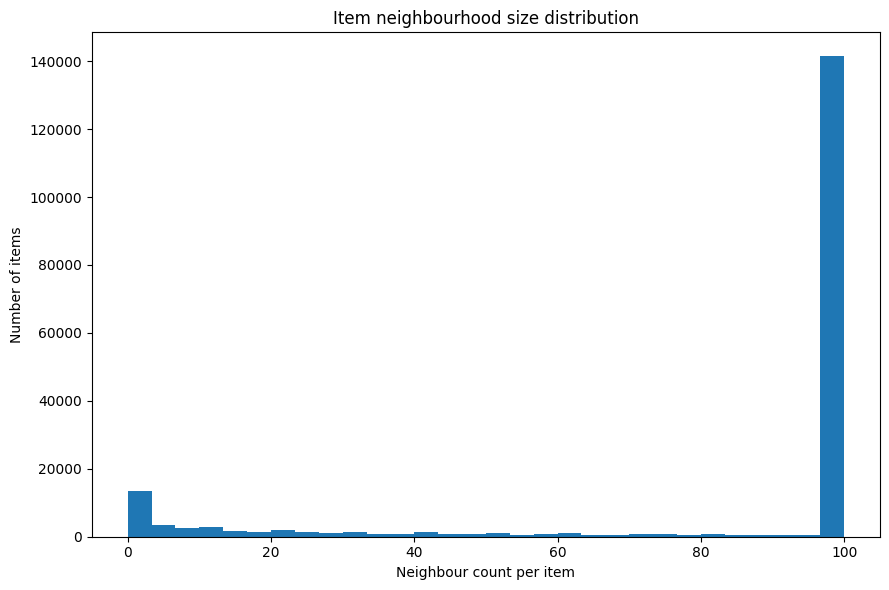

In [28]:
plt.figure(figsize=(9, 6))
plt.hist(neighbour_summary["neighbour_count"], bins=30)
plt.xlabel("Neighbour count per item")
plt.ylabel("Number of items")
plt.title("Item neighbourhood size distribution")
plt.tight_layout()
plt.show()

## 19. Build a compact run summary

In [29]:
run_summary = {
    "model": "item_item_cf_sparse_cosine",
    "train_rows": int(len(train_cf)),
    "valid_rows_cf_evaluable": int(len(valid_cf)),
    "test_rows_cf_evaluable": int(len(test_cf)),
    "train_users": int(train_cf["user_id"].nunique()),
    "train_items": int(train_cf["recipe_id"].nunique()),
    "matrix_shape": [int(train_matrix.shape[0]), int(train_matrix.shape[1])],
    "matrix_nnz": int(train_matrix.nnz),
    "item_neighbour_k": ITEM_NEIGHBOUR_K,
    "top_k_values": TOP_K_VALUES,
    "metrics": cf_metrics.to_dict(orient="records"),
}

run_summary

{'model': 'item_item_cf_sparse_cosine',
 'train_rows': 792656,
 'valid_rows_cf_evaluable': 86979,
 'test_rows_cf_evaluable': 35728,
 'train_users': 106304,
 'train_items': 186564,
 'matrix_shape': [106304, 186564],
 'matrix_nnz': 792656,
 'item_neighbour_k': 100,
 'top_k_values': [5, 10, 20],
 'metrics': [{'split': 'valid',
   'k': 5,
   'users_evaluated': 12493,
   'precision_at_k': 0.0004962779156327545,
   'recall_at_k': 0.0008725157219778443,
   'hit_rate_at_k': 0.002161210277755543,
   'ndcg_at_k': 0.0010446119198575918,
   'novelty_at_k': 19.056634042542353,
   'catalog_coverage_at_k': 0.17777813511717158,
   'recommendation_count': 62331},
  {'split': 'valid',
   'k': 10,
   'users_evaluated': 12493,
   'precision_at_k': 0.00036020171295925716,
   'recall_at_k': 0.0012081468921629577,
   'hit_rate_at_k': 0.0029616585287761147,
   'ndcg_at_k': 0.0010891836387819222,
   'novelty_at_k': 19.107656935716072,
   'catalog_coverage_at_k': 0.2772721425355374,
   'recommendation_count': 1

## 20. Save outputs

In [30]:
cf_split_summary.to_csv(
    TABLES_SUBDIR / "08_cf_split_summary.csv",
    index=False,
)

mapping_summary.to_csv(
    TABLES_SUBDIR / "08_cf_mapping_summary.csv",
    index=False,
)

valid_recommendations_wide.to_csv(
    TABLES_SUBDIR / "08_cf_valid_recommendations_wide.csv",
    index=False,
)

test_recommendations_wide.to_csv(
    TABLES_SUBDIR / "08_cf_test_recommendations_wide.csv",
    index=False,
)

valid_recommendations_long.to_csv(
    TABLES_SUBDIR / "08_cf_valid_recommendations_long.csv",
    index=False,
)

test_recommendations_long.to_csv(
    TABLES_SUBDIR / "08_cf_test_recommendations_long.csv",
    index=False,
)

cf_metrics.to_csv(
    TABLES_SUBDIR / "08_cf_metrics.csv",
    index=False,
)

neighbour_summary.to_csv(
    TABLES_SUBDIR / "08_cf_neighbour_summary.csv",
    index=False,
)

print("CF tables saved to:", TABLES_SUBDIR)

CF tables saved to: E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\outputs\tables\collaborative_filtering


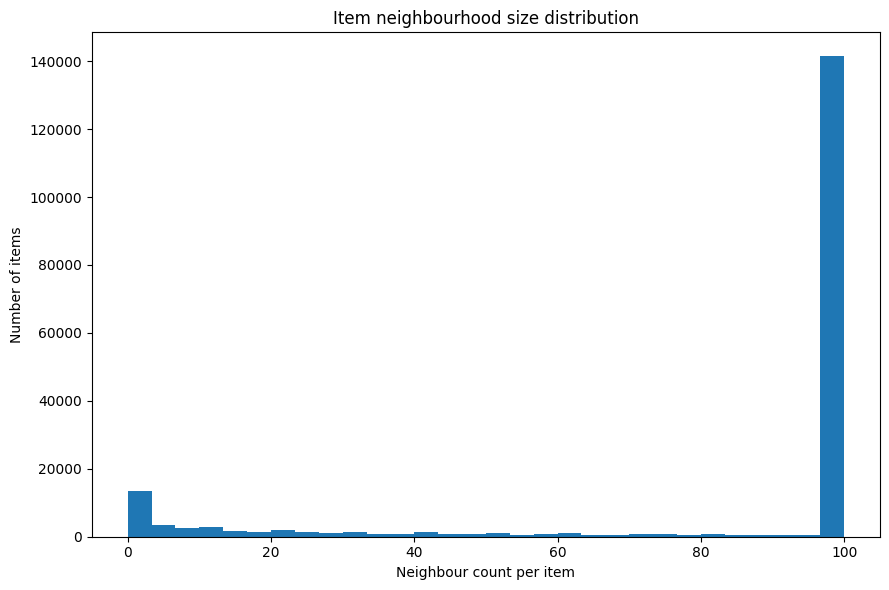

Saved figure to: E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\outputs\figures\collaborative_filtering\08_cf_neighbour_distribution.png


In [31]:
figure_path = FIGURES_SUBDIR / "08_cf_neighbour_distribution.png"

plt.figure(figsize=(9, 6))
plt.hist(neighbour_summary["neighbour_count"], bins=30)
plt.xlabel("Neighbour count per item")
plt.ylabel("Number of items")
plt.title("Item neighbourhood size distribution")
plt.tight_layout()
plt.savefig(figure_path, dpi=200)
plt.show()

print("Saved figure to:", figure_path)

In [32]:
log_path = LOGS_SUBDIR / "08_cf_log.json"

with open(log_path, "w", encoding="utf-8") as f:
    json.dump(run_summary, f, indent=2)

print("Saved log to:", log_path)

Saved log to: E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\outputs\logs\collaborative_filtering\08_cf_log.json


## 21. Final summary

This notebook implemented collaborative filtering using sparse implicit
interactions and item-item cosine similarity.

Key design decisions in this phase:

- the implicit chronological splits were used
- only train-fitted mapped users and items were used for CF scoring
- the training split was converted into a sparse user-item matrix
- cosine similarity was computed between item vectors
- only top neighbours per item were retained for better scaling
- recommendations excluded items already seen in training
- validation and test were evaluated with Top-N ranking metrics
- outputs were saved for later comparison, dashboard integration, and write-up

These outputs are now ready for:

- comparison against the popularity baseline
- later SVD comparison
- unified evaluation tables and charts
- dashboard recommendation demos

In [33]:
print("Saved outputs:")
print("-", TABLES_SUBDIR / "08_cf_split_summary.csv")
print("-", TABLES_SUBDIR / "08_cf_mapping_summary.csv")
print("-", TABLES_SUBDIR / "08_cf_valid_recommendations_wide.csv")
print("-", TABLES_SUBDIR / "08_cf_test_recommendations_wide.csv")
print("-", TABLES_SUBDIR / "08_cf_valid_recommendations_long.csv")
print("-", TABLES_SUBDIR / "08_cf_test_recommendations_long.csv")
print("-", TABLES_SUBDIR / "08_cf_metrics.csv")
print("-", TABLES_SUBDIR / "08_cf_neighbour_summary.csv")
print("-", FIGURES_SUBDIR / "08_cf_neighbour_distribution.png")
print("-", LOGS_SUBDIR / "08_cf_log.json")

print("\nMetrics summary:")
display(cf_metrics)

Saved outputs:
- E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\outputs\tables\collaborative_filtering\08_cf_split_summary.csv
- E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\outputs\tables\collaborative_filtering\08_cf_mapping_summary.csv
- E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\outputs\tables\collaborative_filtering\08_cf_valid_recommendations_wide.csv
- E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\outputs\tables\collaborative_filtering\08_cf_test_recommendations_wide.csv
- E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\outputs\tables\collaborative_filtering\08_cf_valid_recommendations_long.csv
- E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\outputs\tables\collaborative_filtering\08_cf_test_recommendations_long.csv
- E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\outputs\tables\collaborative_filtering\08_cf_metrics.csv
-

,split,k,users_evaluated,precision_at_k,recall_at_k,hit_rate_at_k,ndcg_at_k,novelty_at_k,catalog_coverage_at_k,recommendation_count
0,valid,5,12493,0.000496,0.000873,0.002161,0.001045,19.056634,0.177778,62331
1,valid,10,12493,0.000360,0.001208,0.002962,0.001089,19.107657,0.277272,124468
2,valid,20,12493,0.000324,0.001775,0.005043,0.001258,19.146897,0.392986,248368
3,test,5,5891,0.000340,0.000571,0.001528,0.000615,19.111237,0.104350,29381
4,test,10,5891,0.000272,0.001454,0.002546,0.000842,19.154152,0.176417,58676
5,test,20,5891,0.000212,0.001821,0.003904,0.000938,19.187873,0.274662,117046
